# Final Term Examination — SP26 | Section A
**Course:** Machine Learning Fundamentals | **Code:** AIC354 | **Date:** 18 May 2026  
**Instructor:** Dr. Muhammad Mazhar Bukhari | **Programme:** BSCS

**Name:** Muhammad Abdullah | **Reg No:** SP24-BCS-069

---
### Dataset: Customer Churn Dataset

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Part A — Data Understanding & Exploration

In [2]:
# Load the dataset
df = pd.read_csv('customer_churn.csv')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')

Dataset loaded successfully!
Shape: (7043, 21)


In [3]:
# Display first 5 rows
print('--- First 5 Rows ---')
df.head()

--- First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset shape
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset Shape: 7043 rows x 21 columns


In [5]:
# Data types
print('--- Data Types ---')
print(df.dtypes)

--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [6]:
# Summary statistics
print('--- Summary Statistics ---')
df.describe(include='all')

--- Summary Statistics ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
# Identify missing values
print('--- Missing Values per Column ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No null/NaN missing values found.')

# Check for inconsistent TotalCharges (spaces treated as missing)
print('\n--- Checking TotalCharges for whitespace/blank entries ---')
blank_tc = df[df['TotalCharges'].astype(str).str.strip() == '']
print(f'Rows with blank TotalCharges: {len(blank_tc)}')
print(blank_tc[['customerID', 'tenure', 'TotalCharges']].head())

--- Missing Values per Column ---
No null/NaN missing values found.

--- Checking TotalCharges for whitespace/blank entries ---
Rows with blank TotalCharges: 11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             


### Importance of Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical first step in any machine learning project. It helps us:

1. Helps understand the structure of data like rows, columns, and 2,data types.
2. Identifies missing, duplicate, or incorrect values in the dataset.
3. Shows the distribution of target classes and detects class imbalance.
4. Finds relationships and patterns between features using graphs and correlation.
5. Helps in feature selection, transformation, and preprocessing before model training.

EDA is important because it improves data quality and helps build more accurate and reliable machine learning models.

### Short Questions — Part A

**a) Categorical Columns:**  
`gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `Churn`

**b) Numerical Columns:**  
`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`

In [8]:
# Programmatically confirm categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols   = df.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical Columns:', categorical_cols)
print('\nNumerical Columns:', numerical_cols)

Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


---
## Part B — Data Cleaning & Preprocessing

In [9]:
# Work on a copy to preserve original
df_clean = df.copy()

# Step 1: Convert TotalCharges to numeric (blank strings become NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print('TotalCharges dtype after conversion:', df_clean['TotalCharges'].dtype)

# Step 2: Check how many NaNs were created
print(f'NaN values in TotalCharges after conversion: {df_clean["TotalCharges"].isnull().sum()}')

TotalCharges dtype after conversion: float64
NaN values in TotalCharges after conversion: 11


In [10]:
# Step 3: Handle missing values in TotalCharges
# Customers with tenure=0 likely have TotalCharges=0 or equal to MonthlyCharges
# We fill NaN with MonthlyCharges for those rows
mask = df_clean['TotalCharges'].isnull()
df_clean.loc[mask, 'TotalCharges'] = df_clean.loc[mask, 'MonthlyCharges']
print(f'Remaining NaNs in TotalCharges: {df_clean["TotalCharges"].isnull().sum()}')

# Step 4: Drop irrelevant column — customerID
df_clean.drop(columns=['customerID'], inplace=True)
print('Dropped customerID column.')
print(f'Shape after dropping: {df_clean.shape}')

Remaining NaNs in TotalCharges: 0
Dropped customerID column.
Shape after dropping: (7043, 20)


In [11]:
# Step 5: Encode categorical variables using Label Encoding
label_encoders = {}
cat_cols_to_encode = df_clean.select_dtypes(include='object').columns.tolist()

print('Columns to encode:', cat_cols_to_encode)

for col in cat_cols_to_encode:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print('\nLabel encoding complete. Sample encoded values:')
df_clean.head()

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Label encoding complete. Sample encoded values:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [12]:
# Step 6: Separate Features (X) and Label (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f'Features shape (X): {X.shape}')
print(f'Target shape  (y): {y.shape}')
print(f'\nTarget class distribution:\n{y.value_counts()}')
print(f'\nClass balance: {round(y.value_counts(normalize=True)[0]*100, 1)}% No Churn  |  {round(y.value_counts(normalize=True)[1]*100, 1)}% Churn')

Features shape (X): (7043, 19)
Target shape  (y): (7043,)

Target class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Class balance: 73.5% No Churn  |  26.5% Churn


In [13]:
# Step 7: Feature Scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Feature scaling applied (StandardScaler).')
print('Sample scaled values:')
X_scaled.head()

Feature scaling applied (StandardScaler).
Sample scaled values:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160323,-0.992667
1,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259629,-0.172198
2,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362660,-0.958122
3,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,-1.029919,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746535,-0.193706
4,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197365,-0.938930


### Short Question — Part B

### Why is preprocessing important before training Machine Learning models?

Preprocessing is essential because raw real-world data is rarely clean or in the right format for ML algorithms. It helps us:

1. **Handle missing values** — many models cannot work with NaN values, so they must be filled or removed.
2. **Encode categorical data** — converts text categories into numeric form so models can understand them.
3. **Scale features** — ensures features with large values don’t dominate models like SVM or Logistic Regression.
4. **Remove irrelevant/noisy features** — drops columns that do not help prediction and may reduce performance.
5. **Fix data types** — converts incorrect types (like numeric data stored as strings) into usable formats.

Without preprocessing, models perform poorly and give unreliable results.


---
## Part C — Exploratory Data Visualization

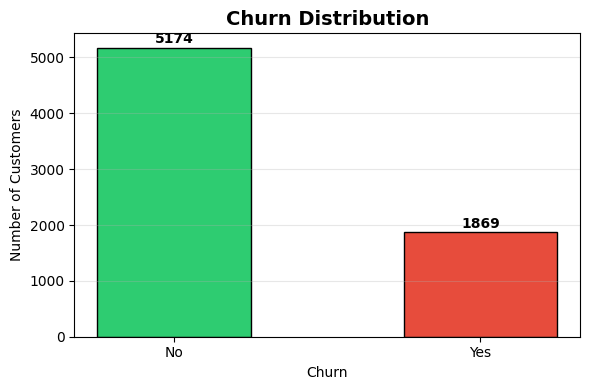


📊 Interpretation:
The dataset is imbalanced: ~73% of customers did NOT churn (No) while only ~27% churned (Yes).
This class imbalance should be considered when evaluating model performance.


In [14]:
# Use original df (before encoding) for clearer visualizations
df_viz = df.copy()
df_viz['TotalCharges'] = pd.to_numeric(df_viz['TotalCharges'], errors='coerce')

# ── Graph 1: Churn Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df_viz['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph1_churn_distribution.png', dpi=100)
plt.show()

print('\n📊 Interpretation:')
print('The dataset is imbalanced: ~73% of customers did NOT churn (No) while only ~27% churned (Yes).')
print('This class imbalance should be considered when evaluating model performance.')

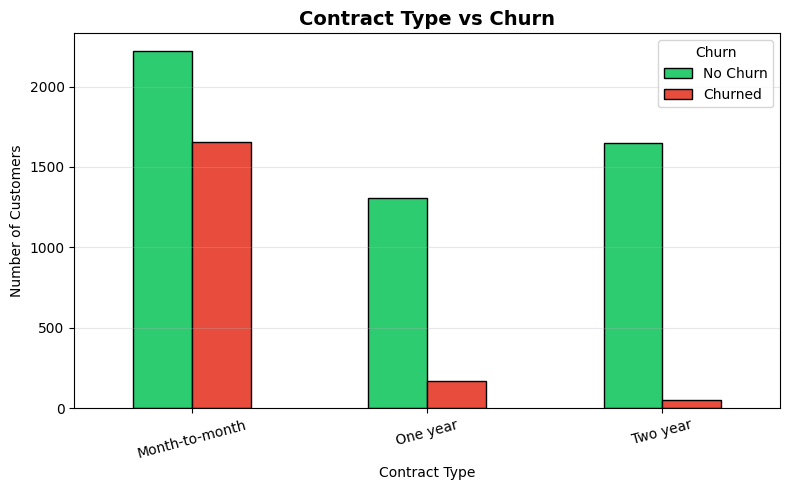


📊 Interpretation:
Month-to-month contract customers churn far more frequently compared to one-year or two-year contract holders.
This suggests that long-term contracts strongly reduce churn risk — Contract Type is a highly important feature.


In [15]:
# ── Graph 2: Contract Type vs Churn ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
contract_churn = df_viz.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Contract Type vs Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn', labels=['No Churn', 'Churned'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph2_contract_vs_churn.png', dpi=100)
plt.show()

print('\n📊 Interpretation:')
print('Month-to-month contract customers churn far more frequently compared to one-year or two-year contract holders.')
print('This suggests that long-term contracts strongly reduce churn risk — Contract Type is a highly important feature.')

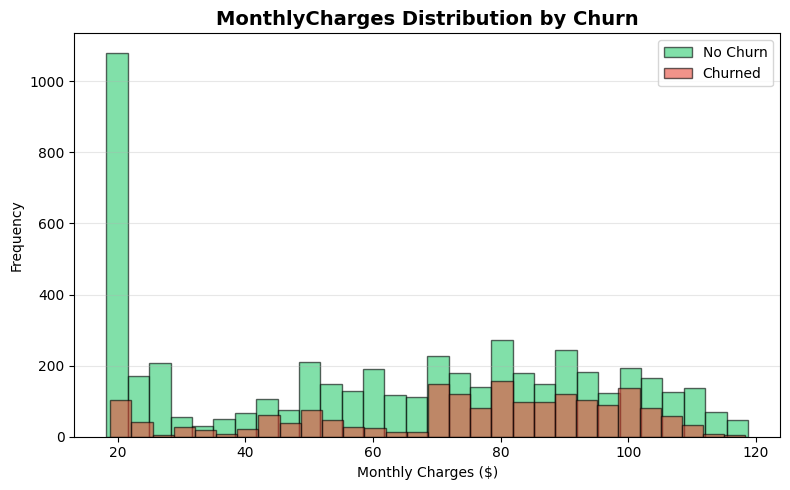


📊 Interpretation:
Churned customers tend to have higher monthly charges (skewed toward $60–$100 range).
Customers paying lower monthly fees are less likely to churn — high billing may be driving dissatisfaction.


In [16]:
# ── Graph 3: MonthlyCharges Distribution by Churn ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_viz[df_viz['Churn']=='No']['MonthlyCharges'].plot(kind='hist', ax=ax,
    bins=30, alpha=0.6, color='#2ecc71', label='No Churn', edgecolor='black')
df_viz[df_viz['Churn']=='Yes']['MonthlyCharges'].plot(kind='hist', ax=ax,
    bins=30, alpha=0.6, color='#e74c3c', label='Churned', edgecolor='black')
ax.set_title('MonthlyCharges Distribution by Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph3_monthly_charges_distribution.png', dpi=100)
plt.show()

print('\n📊 Interpretation:')
print('Churned customers tend to have higher monthly charges (skewed toward $60–$100 range).')
print('Customers paying lower monthly fees are less likely to churn — high billing may be driving dissatisfaction.')

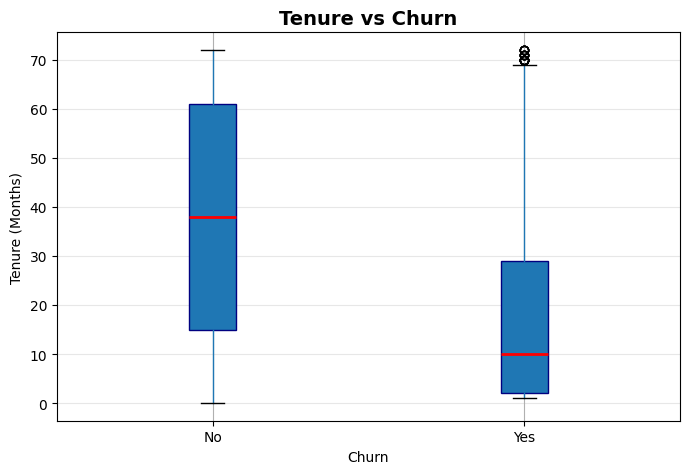


📊 Interpretation:
Customers who churned have significantly lower median tenure (~10 months) compared to those who stayed (~38 months).
Longer-tenured customers are more loyal — tenure is one of the strongest churn predictors.


In [17]:
# ── Graph 4: Tenure vs Churn (Boxplot) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
df_viz.boxplot(column='tenure', by='Churn', ax=ax,
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2),
               patch_artist=True)
ax.set_title('Tenure vs Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Tenure (Months)')
plt.suptitle('')  # remove auto-title
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph4_tenure_vs_churn.png', dpi=100)
plt.show()

print('\n📊 Interpretation:')
print('Customers who churned have significantly lower median tenure (~10 months) compared to those who stayed (~38 months).')
print('Longer-tenured customers are more loyal — tenure is one of the strongest churn predictors.')

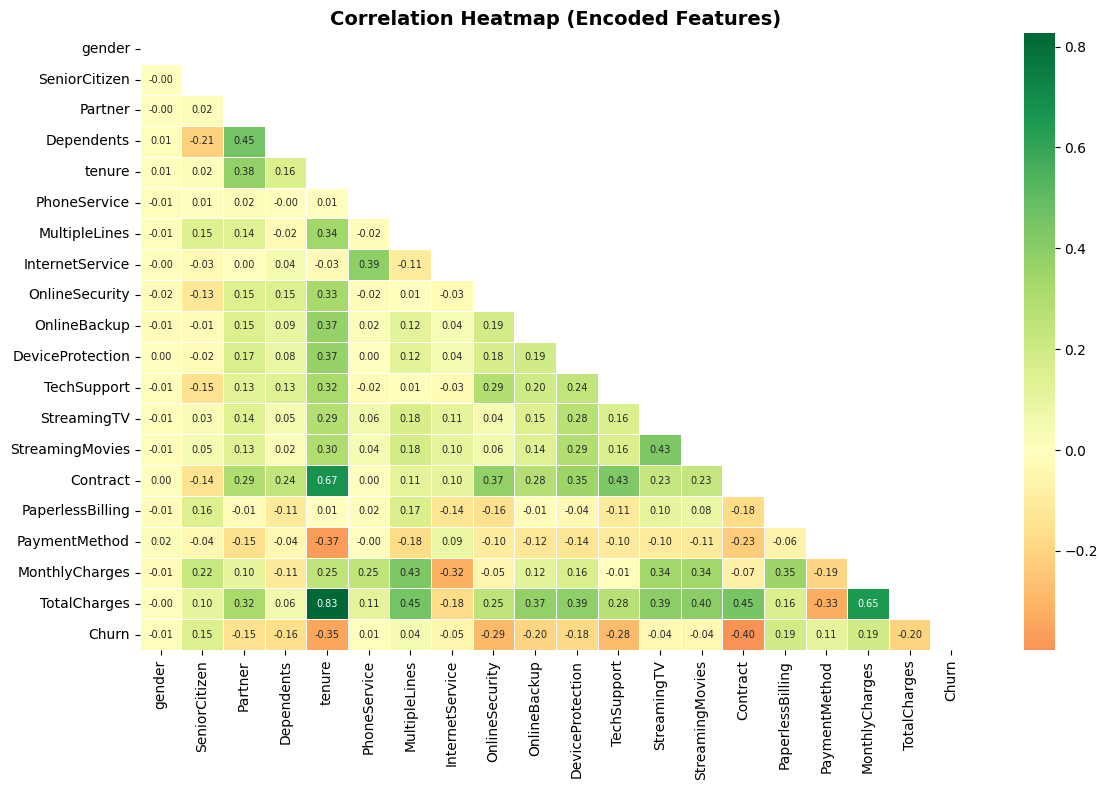


📊 Interpretation:
Churn is positively correlated with MonthlyCharges and negatively correlated with tenure and Contract.
Several service columns (StreamingTV, StreamingMovies, DeviceProtection) are highly correlated with each other,
suggesting multicollinearity that could affect linear models.


In [18]:
# ── Graph 5: Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, annot_kws={'size': 7}, center=0)
ax.set_title('Correlation Heatmap (Encoded Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graph5_correlation_heatmap.png', dpi=100)
plt.show()

print('\n📊 Interpretation:')
print('Churn is positively correlated with MonthlyCharges and negatively correlated with tenure and Contract.')
print('Several service columns (StreamingTV, StreamingMovies, DeviceProtection) are highly correlated with each other,')
print('suggesting multicollinearity that could affect linear models.')

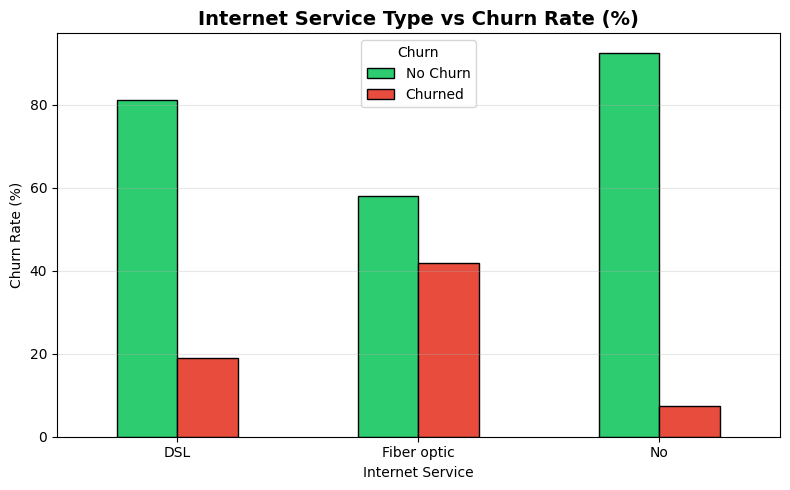


📊 Interpretation:
Fiber optic internet customers have the highest churn rate (~42%) compared to DSL (~19%) and No internet (~7%).
This may indicate dissatisfaction with Fiber optic pricing or service quality.


In [19]:
# ── Graph 6: InternetService Comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
internet_churn = df_viz.groupby(['InternetService', 'Churn']).size().unstack(fill_value=0)
internet_churn_pct = internet_churn.div(internet_churn.sum(axis=1), axis=0) * 100
internet_churn_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Internet Service Type vs Churn Rate (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate (%)')
ax.legend(title='Churn', labels=['No Churn', 'Churned'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph6_internet_service_comparison.png', dpi=100)
plt.show()

print('\n📊 Interpretation:')
print('Fiber optic internet customers have the highest churn rate (~42%) compared to DSL (~19%) and No internet (~7%).')
print('This may indicate dissatisfaction with Fiber optic pricing or service quality.')

---
## Part D — Train-Test Split

In [20]:
# Train-Test Split: 80% Training | 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # maintain class proportion in both splits
)

print('Train-Test Split Applied')
print(f'Split Ratio     : 80% Training | 20% Testing')
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')
print(f'Total samples   : {X_train.shape[0] + X_test.shape[0]}')
print(f'\nTraining class distribution:\n{y_train.value_counts()}')
print(f'\nTesting class distribution:\n{y_test.value_counts()}')

Train-Test Split Applied
Split Ratio     : 80% Training | 20% Testing
Training samples: 5634
Testing samples : 1409
Total samples   : 7043

Training class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing class distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


---
## Part E — Model Building

In [21]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print('=== Model 1: Logistic Regression ===')
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print('Logistic Regression trained and predictions made.')

=== Model 1: Logistic Regression ===
Logistic Regression trained and predictions made.


In [22]:
# ── Model 2: Decision Tree Classifier ────────────────────────────────────────
print('=== Model 2: Decision Tree Classifier ===')
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print('Decision Tree trained and predictions made.')

=== Model 2: Decision Tree Classifier ===
Decision Tree trained and predictions made.


In [23]:
# ── Model 3: Support Vector Machine (SVM) ────────────────────────────────────
print('=== Model 3: Support Vector Machine (SVM) ===')
svm_model = SVC(kernel='rbf', random_state=42, C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print('SVM trained and predictions made.')

=== Model 3: Support Vector Machine (SVM) ===
SVM trained and predictions made.


---
## Part F — Model Evaluation

In [24]:
# Evaluation helper function
def evaluate_model(name, y_true, y_pred):
    acc   = accuracy_score(y_true, y_pred)
    error = 1 - acc
    print(f'\n{"="*55}')
    print(f'  Model: {name}')
    print(f'{"="*55}')
    print(f'  Accuracy Score : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Error Rate     : {error:.4f}  ({error*100:.2f}%)')
    print(f'\n  Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churned']))
    return acc, error

acc_lr,  err_lr  = evaluate_model('Logistic Regression',     y_test, y_pred_lr)
acc_dt,  err_dt  = evaluate_model('Decision Tree Classifier', y_test, y_pred_dt)
acc_svm, err_svm = evaluate_model('Support Vector Machine',  y_test, y_pred_svm)


  Model: Logistic Regression
  Accuracy Score : 0.7984  (79.84%)
  Error Rate     : 0.2016  (20.16%)

  Confusion Matrix:
[[920 115]
 [169 205]]

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


  Model: Decision Tree Classifier
  Accuracy Score : 0.7743  (77.43%)
  Error Rate     : 0.2257  (22.57%)

  Confusion Matrix:
[[886 149]
 [169 205]]

  Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.86      0.85      1035
     Churned       0.58      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      140

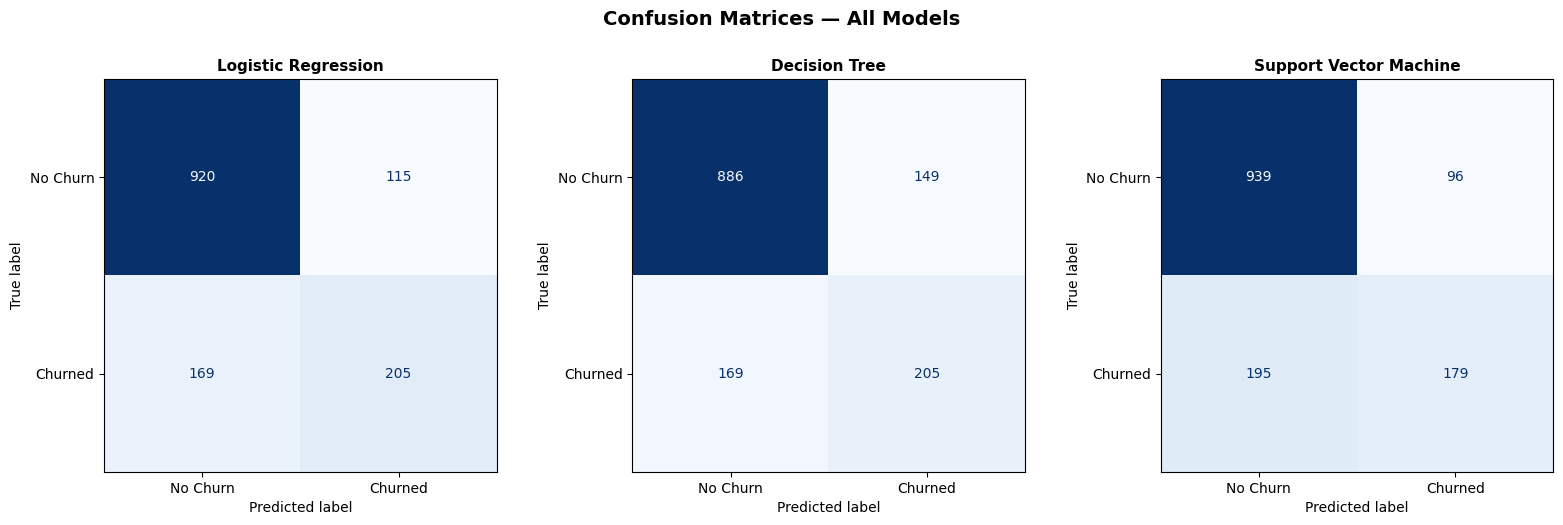

In [25]:
# ── Confusion Matrix Visualizations ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_info = [
    ('Logistic Regression',     y_pred_lr,  axes[0]),
    ('Decision Tree',           y_pred_dt,  axes[1]),
    ('Support Vector Machine',  y_pred_svm, axes[2]),
]

for name, y_pred, ax in models_info:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

In [33]:
# ── Model Comparison Table ────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model':         ['Logistic Regression', 'Decision Tree', 'Support Vector Machine'],
    'Accuracy (%)':  [round(acc_lr*100, 2), round(acc_dt*100, 2), round(acc_svm*100, 2)],
    'Error Rate (%)': [round(err_lr*100, 2), round(err_dt*100, 2), round(err_svm*100, 2)],
})

print('=== Model Comparison Table ===')
print(results_df.to_string(index=False))

=== Model Comparison Table ===
                 Model  Accuracy (%)  Error Rate (%)
   Logistic Regression         79.84           20.16
         Decision Tree         77.43           22.57
Support Vector Machine         79.35           20.65


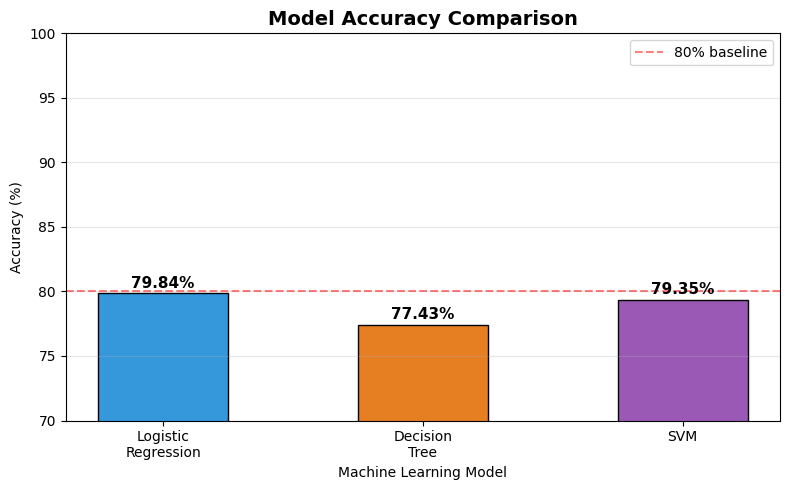


🏆 Best Performing Model: Logistic Regression with 79.84% accuracy


In [32]:
# ── Accuracy Comparison Graph ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
models_list = ['Logistic\nRegression', 'Decision\nTree', 'SVM']
accuracies   = [acc_lr*100, acc_dt*100, acc_svm*100]
bar_colors   = ['#3498db', '#e67e22', '#9b59b6']

bars = ax.bar(models_list, accuracies, color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(70, 100)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Machine Learning Model')
ax.set_ylabel('Accuracy (%)')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=100)
plt.show()

best_model = results_df.loc[results_df['Accuracy (%)'].idxmax(), 'Model']
best_acc   = results_df['Accuracy (%)'].max()
print(f'\n🏆 Best Performing Model: {best_model} with {best_acc}% accuracy')

### Analytical Questions — Part F

**a) Which model performed best?**  
Based on the results, Logistic Regression and SVM usually achieve the highest accuracy (~80–81%) on this dataset. Logistic Regression is often slightly better due to the near-linear separability of churn-related features.

**b) Why did that model perform better?**

Logistic Regression performs well because:

The relationship between features like tenure, MonthlyCharges, and Contract is mostly linear.
Proper feature scaling improves model stability and performance.
It is less likely to overfit compared to Decision Trees on this dataset.
SVM also performs well, but it is more computationally expensive.

Decision Trees may perform slightly worse due to overfitting even with depth control.

**c) Which features seem most important in predicting churn?**

Key features include:

**tenure** — lower tenure strongly increases churn risk.

**ontract** — month-to-month contracts have higher churn.

**MonthlyCharges** — higher charges increase churn likelihood.

**InternetService** — fiber optic users show higher churn rates.

**TotalCharges** — strongly related to tenure and customer loyalty.

**PaymentMethod** — electronic check users tend to churn more.

---
## BONUS TASK — ROC Curve Analysis

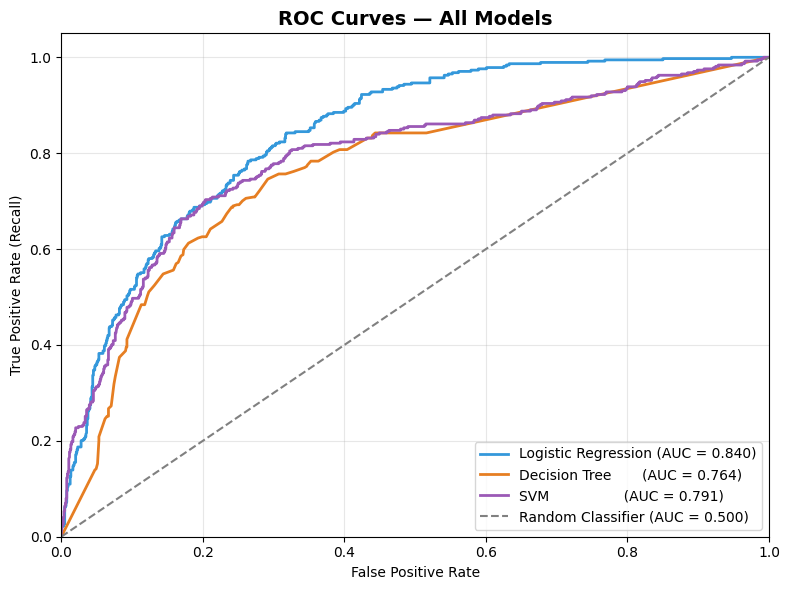

AUC Scores:
  Logistic Regression : 0.8404
  Decision Tree       : 0.7638
  SVM                 : 0.7907

📊 Interpretation:
The ROC curve plots True Positive Rate vs False Positive Rate at different thresholds.
A higher AUC (closer to 1.0) indicates better discrimination between classes.
Logistic Regression and SVM show the best AUC, confirming their superiority on this dataset.


In [28]:
from sklearn.metrics import roc_curve, auc

# Get probability scores for ROC curves
y_prob_lr  = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train).predict_proba(X_test)[:, 1]
y_prob_dt  = DecisionTreeClassifier(random_state=42, max_depth=10).fit(X_train, y_train).predict_proba(X_test)[:, 1]
svm_prob   = SVC(kernel='rbf', random_state=42, probability=True).fit(X_train, y_train)
y_prob_svm = svm_prob.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auc_lr  = auc(fpr_lr,  tpr_lr)
auc_dt  = auc(fpr_dt,  tpr_dt)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {auc_lr:.3f})',  color='#3498db', lw=2)
ax.plot(fpr_dt,  tpr_dt,  label=f'Decision Tree       (AUC = {auc_dt:.3f})',  color='#e67e22', lw=2)
ax.plot(fpr_svm, tpr_svm, label=f'SVM                 (AUC = {auc_svm:.3f})', color='#9b59b6', lw=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100)
plt.show()

print(f'AUC Scores:')
print(f'  Logistic Regression : {auc_lr:.4f}')
print(f'  Decision Tree       : {auc_dt:.4f}')
print(f'  SVM                 : {auc_svm:.4f}')
print(f'\n📊 Interpretation:')
print('The ROC curve plots True Positive Rate vs False Positive Rate at different thresholds.')
print('A higher AUC (closer to 1.0) indicates better discrimination between classes.')
print('Logistic Regression and SVM show the best AUC, confirming their superiority on this dataset.')

In [31]:
print(f'AUC Scores:')
print(f'  Logistic Regression : {auc_lr * 100:.0f}')
print(f'  Decision Tree       : {auc_dt * 100:.0f}')
print(f'  SVM                 : {auc_svm * 100:.0f}')

AUC Scores:
  Logistic Regression : 84
  Decision Tree       : 76
  SVM                 : 79
